# Imports

In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('playground-series-s6e8')

100%|██████████| 19.7M/19.7M [00:00<00:00, 182MB/s]

Extracting files...


Kaggle credentials set.
Kaggle credentials successfully validated.


In [8]:
path

'/root/.cache/kagglehub/competitions/playground-series-s6e8'

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
df_test = pd.read_csv(f'{path}/test.csv')
df_train = pd.read_csv(f'{path}/train.csv')

In [ ]:
# df_test =  pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/test.csv')
# df_train =  pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/train.csv')

In [ ]:
df_test =  pd.read_csv('test.csv')
df_train =  pd.read_csv('train.csv')

In [ ]:
df_test['source'] = 'test'
df_train['source'] = 'train'

In [ ]:
df = pd.concat(
    [df_train, df_test],
    ignore_index = True
)

In [ ]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,source
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1.0,train
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0.0,train
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0.0,train
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1.0,train
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1.0,train


# Info

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,987671.0,493835.000000,285116.203198,0.00,246917.50,493835.00,740752.50,987670.00
age,941604.0,26.613416,5.153219,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,859029.0,7.640836,2.722818,0.50,5.46,7.77,9.84,15.00
social_media_hours,806279.0,2.471096,1.316756,0.00,1.45,2.31,3.37,8.00
gaming_hours,801430.0,1.458793,0.934603,0.00,0.70,1.33,2.09,4.00
work_study_hours,908376.0,2.366673,1.258272,0.00,1.36,2.20,3.20,6.00
sleep_hours,920736.0,6.803552,1.234978,4.50,5.77,6.80,7.87,9.00
notifications_per_day,885866.0,145.851459,65.946264,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,881256.0,102.642749,48.122283,15.00,63.00,104.00,145.00,180.00
weekend_screen_time,824911.0,9.478291,2.856713,0.51,7.27,9.58,11.75,17.56


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987671 entries, 0 to 987670
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       987671 non-null  int64  
 1   age                      941604 non-null  float64
 2   daily_screen_time_hours  859029 non-null  float64
 3   social_media_hours       806279 non-null  float64
 4   gaming_hours             801430 non-null  float64
 5   work_study_hours         908376 non-null  float64
 6   sleep_hours              920736 non-null  float64
 7   notifications_per_day    885866 non-null  float64
 8   app_opens_per_day        881256 non-null  float64
 9   weekend_screen_time      824911 non-null  float64
 10  gender                   944425 non-null  object 
 11  stress_level             912897 non-null  object 
 12  academic_work_impact     917726 non-null  object 
 13  addicted_label           691369 non-null  float64
 14  sour

In [ ]:
df.isna().sum()

id                              0
age                         46067
daily_screen_time_hours    128642
social_media_hours         181392
gaming_hours               186241
work_study_hours            79295
sleep_hours                 66935
notifications_per_day      101805
app_opens_per_day          106415
weekend_screen_time        162760
gender                      43246
stress_level                74774
academic_work_impact        69945
addicted_label             296302
source                          0
dtype: int64

<Axes: xlabel='addicted_label', ylabel='count'>

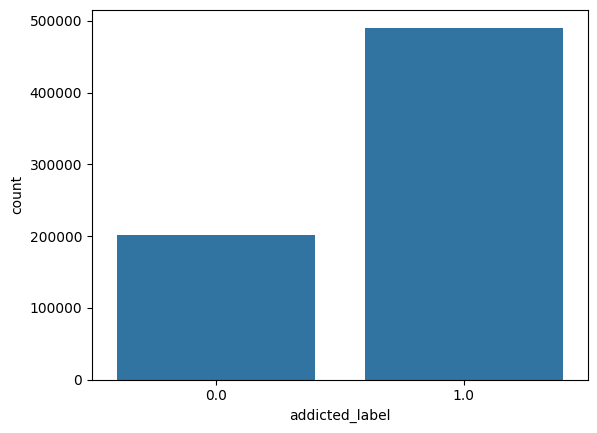

In [ ]:
sns.countplot(
    data=df,
    x='addicted_label'
)

In [ ]:
df['addicted_label'].value_counts(normalize=True)

addicted_label
1.0    0.709424
0.0    0.290576
Name: proportion, dtype: float64

In [ ]:
df['id'].nunique()

987671

# EDA

<Axes: >

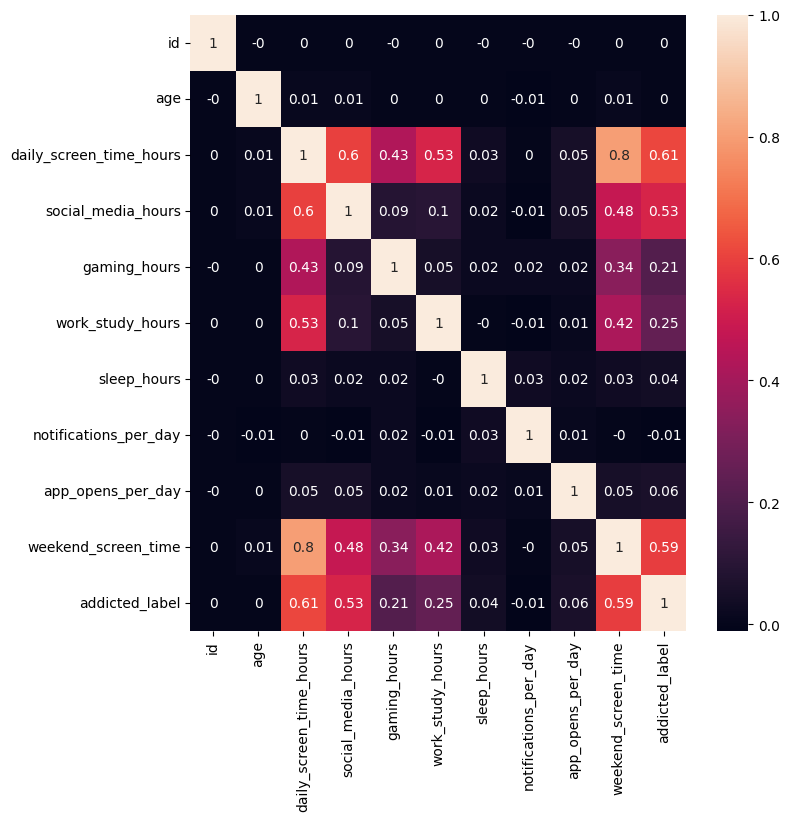

In [ ]:
correlations = df[df['source']=='train'].select_dtypes(include='number').corr()

plt.figure(figsize=(8,8))
sns.heatmap(
    data=correlations.round(2),
    annot=True,
)

Text(0.5, 1.0, 'Age distribution by Addicted Label')

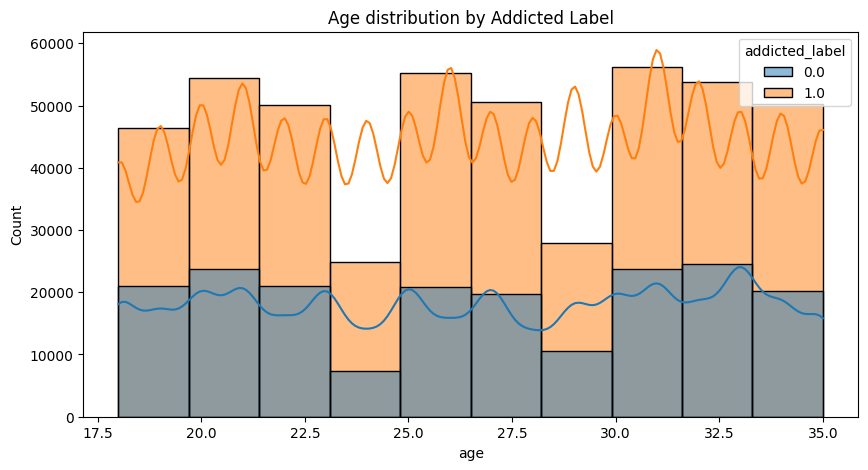

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='age',
    bins = 10,
    hue='addicted_label',
    kde=True
)
plt.title('Age distribution by Addicted Label')

Text(0.5, 1.0, 'Age distribution by Gender')

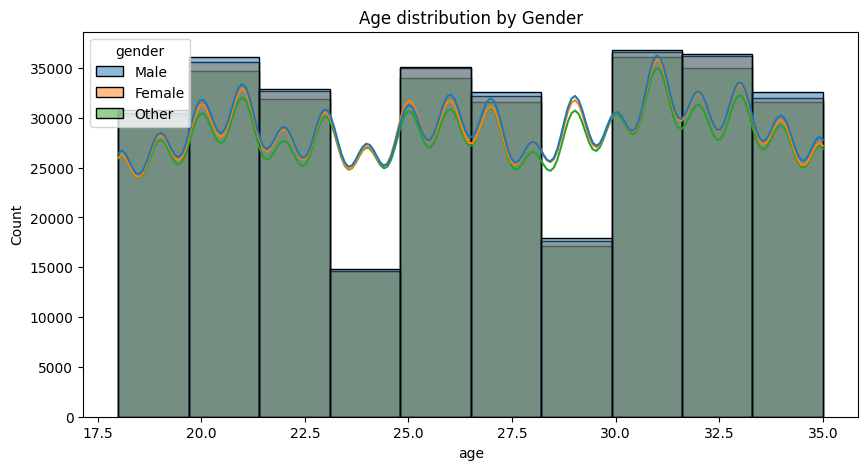

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='age',
    bins = 10,
    hue='gender',
    kde=True
)
plt.title('Age distribution by Gender')

Text(0.5, 1.0, 'Addcition Distribtuion by Age')

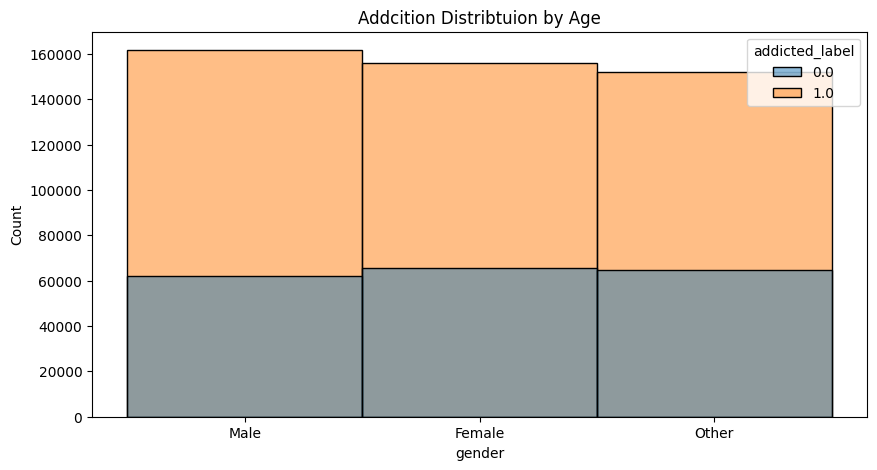

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='gender',
    bins = 10,
    hue='addicted_label'
)
plt.title('Addcition Distribtuion by Age')

## Missing Values

In [ ]:
null_columns = (pd.DataFrame(df.isna().sum(),
             index=df.isna().sum().index,
             columns=['num_missing']
            ))
null_columns['pct_missing'] = (null_columns['num_missing'] / len(df)).round(2)
print(null_columns)

                         num_missing  pct_missing
id                                 0         0.00
age                            46067         0.05
daily_screen_time_hours       128642         0.13
social_media_hours            181392         0.18
gaming_hours                  186241         0.19
work_study_hours               79295         0.08
sleep_hours                    66935         0.07
notifications_per_day         101805         0.10
app_opens_per_day             106415         0.11
weekend_screen_time           162760         0.16
gender                         43246         0.04
stress_level                   74774         0.08
academic_work_impact           69945         0.07
addicted_label                296302         0.30
source                             0         0.00


In [ ]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label',
       'source'],
      dtype='object')

In [ ]:
for col in df.drop(columns=['id', 'source', 'addicted_label'], axis=1).columns:
    df[f'{col}_is_missing'] = df[col].isnull().astype(int)

# Feature Engineering

In [ ]:
# Map academic work impact to 1 / 0

df['academic_work_impact'] = df['academic_work_impact'].map({'Yes': 1, 'No': 0})

# Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_validate, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,source,age_is_missing,daily_screen_time_hours_is_missing,social_media_hours_is_missing,gaming_hours_is_missing,work_study_hours_is_missing,sleep_hours_is_missing,notifications_per_day_is_missing,app_opens_per_day_is_missing,weekend_screen_time_is_missing,gender_is_missing,stress_level_is_missing,academic_work_impact_is_missing
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,0.0,1.0,train,0,1,0,0,0,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,0.0,0.0,train,0,0,0,1,0,0,0,0,1,0,0,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,1.0,0.0,train,0,0,1,1,1,0,0,0,0,0,0,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1.0,train,0,0,0,0,0,0,0,0,0,0,0,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,0.0,1.0,train,0,0,0,0,0,0,1,1,0,0,0,0


## Data Preparation

In [ ]:
target = 'addicted_label'
drop_features = ['id', 'addicted_label', 'source']
numerical_features = [col for col in df.select_dtypes(include='number').columns if col not in ['addicted_label', 'id']]
categorical_features = ['gender', 'stress_level']

In [ ]:
training_set = df[df['source'] == 'train']
testing_set = df[df['source'] == 'test'].drop(drop_features, axis=1)

In [ ]:
X = training_set.drop(drop_features, axis=1)
y = training_set[target]

## Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore',drop=None),categorical_features)
        # ('num', SimpleImputer(strategy='median'), numerical_features)
    ],
    remainder='passthrough'
)

In [ ]:
xgb = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.8
)

In [ ]:
model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', xgb)
])

## Cross Validation

In [ ]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True
)

In [ ]:
scores = cross_validate(
    estimator=model,
    X=X,
    y=y,
    return_train_score=True,
    cv=cv,
    # n_jobs = 5,
    scoring='roc_auc',
    verbose=3
)

[CV] END ..................., score=(train=0.961, test=0.958) total time=   5.6s
[CV] END ..................., score=(train=0.961, test=0.958) total time=   5.9s
[CV] END ..................., score=(train=0.961, test=0.957) total time=   5.6s
[CV] END ..................., score=(train=0.961, test=0.958) total time=   6.2s
[CV] END ..................., score=(train=0.961, test=0.958) total time=   6.3s


In [ ]:
print(f"Train roc_auc: {scores.get('train_score').mean().round(5)} +- {scores.get('train_score').mean().round(5).std()}")
print(f"Test roc_auc: {scores.get('test_score').mean().round(5)} +- {scores.get('test_score').mean().round(5).std()}")

Train roc_auc: 0.96098 +- 0.0
Test roc_auc: 0.95784 +- 0.0


## Hyperparameter Tuning

## Fitting

In [ ]:
model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'stress_level'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

<Axes: xlabel='importance', ylabel='feature'>

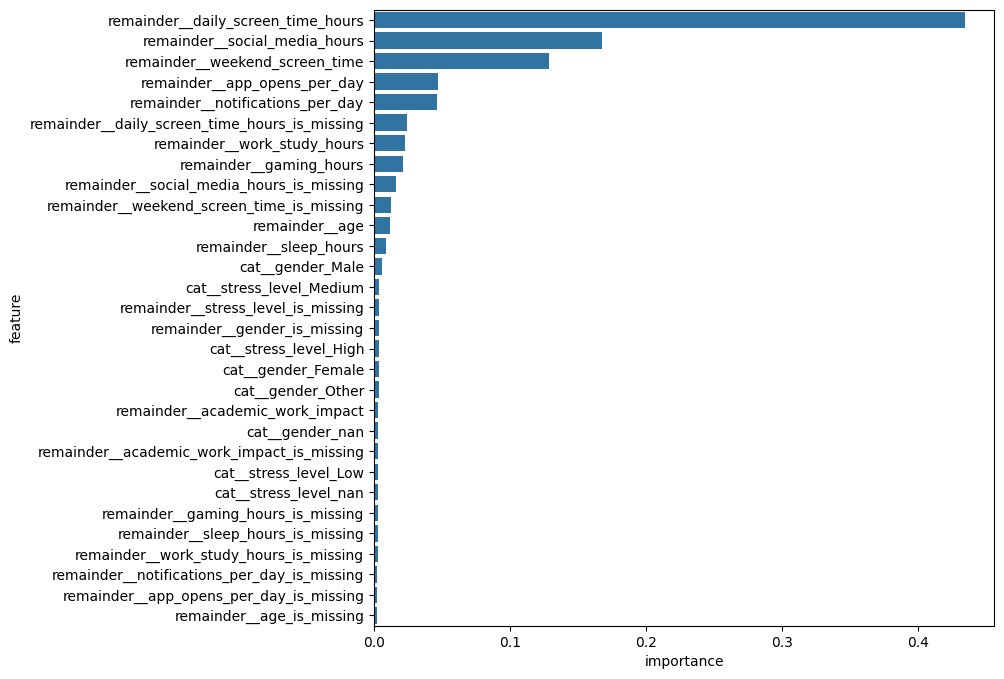

In [ ]:
feature_columns = model.named_steps['preprocess'].get_feature_names_out()
importances = model.named_steps['clf'].feature_importances_

plt.figure(figsize=(8,8))
importances_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
}).sort_values('importance', ascending=False)

sns.barplot(
    data=importances_df,
    x='importance',
    y='feature'
)

# Submission

In [ ]:
results = model.predict_proba(testing_set)

In [ ]:
model.classes_

array([0, 1])

In [ ]:
results[:, 1]

array([0.9982399 , 0.88295144, 0.9707159 , ..., 0.22591843, 0.5934783 ,
       0.6612899 ], dtype=float32)

In [ ]:
df_test['addicted_label'] = results[:, 1]
display(df_test[['id', 'addicted_label']].head())

id,addicted_label
691369,0.9982399
691370,0.88295144
691371,0.9707159
691372,0.9753587
691373,0.9964922


In [ ]:
# df_test[['id', 'addicted_label']].to_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/submission_v1.csv', index=False)

In [ ]:
# df_test[['id', 'addicted_label']].to_csv('submission_v2.csv', index=False)